# 📦 Week 2: Data Collection, Cleaning, and Preprocessing in Logistics Analysis
### *Domain: Indian Multi-Carrier Logistics & Supply Chain Telematics (25,000 Dispatches)*
**Author**: Logistics Data Analyst Intern  
**Dataset**: Multi-carrier shipment telemetry across North, South, East, West, and Central India hubs.

---

## 🎯 Executive Objectives
1. **Simulate Data Collection & Telematics Ingestion**: Ingest 25,000 multi-carrier shipment records across 9 leading 3PL carriers (Delhivery, Blue Dart, Xpressbees, Shadowfax, Ekart, Ecom Express, FedEx, DHL, Amazon Logistics).
2. **Comprehensive Data Quality Audit**: Diagnose duplicate tracking IDs, missingness structures (MCAR/MAR/MNAR), string timestamp placeholders, and sensor failures.
3. **Outlier Detection & Remediation Engine**: Implement and benchmark **Tukey's IQR**, **Z-Score ($>3\sigma$)**, **Quantile Winsorization**, and **Isolation Forest** multivariate anomaly detection.
4. **Domain-Driven Feature Engineering**: Construct operational metrics including **Cost per KM (CPK)**, **Effective Transit Speed ($km/h$)**, **SLA Variance ($\Delta t$)**, **Green Fleet EV indicator**, and **Adverse Weather Risk Factor**.
5. **Feature Scaling & Transformation**: Benchmark **StandardScaler**, **MinMaxScaler**, and **RobustScaler**, and apply **Log1p** variance stabilization.
6. **Export Production-Ready Dataset**: Export the fully cleaned, transformed, and feature-engineered dataset for downstream machine learning and BI dashboards.


## 1. Environment Setup & Library Ingestion

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.ensemble import IsolationForest

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

print("[+] Environment initialized with Pandas, NumPy, Scikit-Learn, SciPy, and Matplotlib.")


[+] Environment initialized with Pandas, NumPy, Scikit-Learn, SciPy, and Matplotlib.


## 2. Data Collection Simulation & Ingestion

In [2]:
# Load raw shipment telemetry dataset
raw_data_path = "../week-1/Delivery_Logistics.csv" if os.path.exists("../week-1/Delivery_Logistics.csv") else "week-1/Delivery_Logistics.csv"
df_raw = pd.read_csv(raw_data_path)

print(f"[*] Successfully ingested {df_raw.shape[0]:,} records with {df_raw.shape[1]} raw attributes.")
print(f"[*] Indian 3PL Carriers: {df_raw['delivery_partner'].unique().tolist()}")
print(f"[*] Geographic Regions: {df_raw['region'].unique().tolist()}")
df_raw.head(5)


[*] Successfully ingested 25,000 records with 15 raw attributes.
[*] Indian 3PL Carriers: ['delhivery', 'xpressbees', 'shadowfax', 'dhl', 'amazon logistics', 'blue dart', 'fedex', 'ecom express', 'ekart']
[*] Geographic Regions: ['west', 'central', 'east', 'north', 'south']


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,00:00.0,00:00.0,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,00:00.0,00:00.0,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,00:00.0,00:00.0,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,00:00.0,00:00.0,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,00:00.0,00:00.0,no,delivered,4,1394.5600


## 3. Data Quality Audit & Anomaly Profiling
Before applying preprocessing transformations, we conduct a diagnostic audit:
- Check for explicit and implicit null values.
- Verify identifier uniqueness.
- Profile timestamp string formatting.
- Detect distribution boundaries across numeric features.


In [3]:
# 1. Null Value Check
null_summary = df_raw.isnull().sum()

# 2. Key Uniqueness Check
duplicate_ids = df_raw['delivery_id'].duplicated().sum()

# 3. Timestamp String Analysis
sample_timestamps = df_raw['delivery_time_hours'].value_counts().head(3)

print("=== DATA QUALITY DIAGNOSTIC SUMMARY ===")
print(f"Total Records: {len(df_raw):,}")
print("Missing Values (Explicit NaNs):")
print(null_summary[null_summary > 0] if null_summary.sum() > 0 else "Zero explicit NaNs")
print(f"Duplicate / Collision delivery_id Count: {duplicate_ids:,} ({duplicate_ids/len(df_raw)*100:.2f}%)")
print(f"Timestamp Placeholder Frequency ('00:00.0'): {sample_timestamps.to_dict()}")

df_raw.describe().T


=== DATA QUALITY DIAGNOSTIC SUMMARY ===
Total Records: 25,000
Missing Values (Explicit NaNs):
Zero explicit NaNs
Duplicate / Collision delivery_id Count: 498 (1.99%)
Timestamp Placeholder Frequency ('00:00.0'): {'00:00.0': 25000}


,count,mean,std,min,25%,50%,75%,max
delivery_id,25000.0,12500.500000,7212.732314,250.9900,6250.75,12500.500,18750.25,24750.0100
distance_km,25000.0,150.390436,86.409745,3.6000,75.90,151.000,224.90,297.1000
package_weight_kg,25000.0,25.145898,14.368663,0.6700,12.68,25.145,37.66,49.5200
delivery_rating,25000.0,3.666000,1.149964,1.0000,3.00,4.000,5.00,5.0000
delivery_cost,25000.0,864.944579,435.712593,95.6674,490.80,867.535,1237.91,1632.7206


## 4. Data Cleaning & Re-Identification Pipeline
1. **Surrogate Key Generation**: Assign unique alphanumeric dispatch UUIDs (`DEL-IND-00001` to `DEL-IND-25000`).
2. **String Casing Normalization**: Standardize all categorical text fields to lowercase and strip whitespace.


In [4]:
df = df_raw.copy()

# Generate unique primary surrogate keys
df['shipment_uid'] = [f"DEL-IND-{i+1:05d}" for i in range(len(df))]

# Clean and normalize categorical text strings
text_columns = ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'delivery_status']
for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

print(f"[+] Assigned unique 'shipment_uid' surrogate keys. Head: {df['shipment_uid'].head(3).tolist()}")
print(f"[+] Text normalized across columns: {text_columns}")


[+] Assigned unique 'shipment_uid' surrogate keys. Head: ['DEL-IND-00001', 'DEL-IND-00002', 'DEL-IND-00003']
[+] Text normalized across columns: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'delivery_status']


## 5. Handling Missing Telemetry: Kinematic Transit Duration Model
In real-world Indian supply chains, sensor dropouts can leave timestamps masked (e.g. `'00:00.0'`).
We reconstruct realistic operational transit times and SLA variance using kinematic parameters:
$$	ext{Transit Time} = rac{	ext{Distance}}{	ext{Base Speed} / 	ext{Weather Impedance}} + \epsilon_{	ext{traffic}} + 	ext{Delay Penalty}$$


In [5]:
np.random.seed(42)

# Contract SLA expected hours
mode_expected_hours = {
    'same day': 8.0,
    'express': 18.0,
    'two day': 48.0,
    'standard': 72.0
}
df['expected_transit_hours'] = df['delivery_mode'].map(mode_expected_hours)

# Weather speed impedance multipliers in India
weather_impedance = {
    'clear': 1.00, 'mild': 1.02, 'cold': 1.08, 'hot': 1.05,
    'foggy': 1.25, 'rainy': 1.35, 'stormy': 1.55
}
impedance = df['weather_condition'].map(lambda x: weather_impedance.get(x, 1.10))

# Vehicle baseline speeds (km/h)
vehicle_base_speed = {
    'bike': 32.0, 'ev bike': 30.0, 'scooter': 28.0,
    'van': 42.0, 'ev van': 40.0, 'truck': 45.0
}
base_spd = df['vehicle_type'].map(lambda x: vehicle_base_speed.get(x, 35.0))

# Compute actual transit duration
transit_time = (df['distance_km'] / (base_spd / impedance)) + np.random.exponential(scale=1.2, size=len(df))
delayed_mask = df['delayed'] == 'yes'
transit_time[delayed_mask] += np.random.uniform(4.0, 18.0, size=delayed_mask.sum())

df['actual_transit_hours'] = np.round(transit_time, 2)
df['effective_speed_kmh'] = np.round(df['distance_km'] / np.maximum(df['actual_transit_hours'], 0.1), 2)
df['sla_variance_hours'] = np.round(df['actual_transit_hours'] - df['expected_transit_hours'], 2)

print("[+] Reconstructed transit telemetry and SLA variance metrics.")
df[['shipment_uid', 'delivery_mode', 'expected_transit_hours', 'actual_transit_hours', 'sla_variance_hours', 'effective_speed_kmh']].head()


[+] Reconstructed transit telemetry and SLA variance metrics.


,shipment_uid,delivery_mode,expected_transit_hours,actual_transit_hours,sla_variance_hours,effective_speed_kmh
0,DEL-IND-00001,same day,8.0,9.84,1.84,30.18
1,DEL-IND-00002,express,18.0,6.03,-11.97,14.86
2,DEL-IND-00003,two day,48.0,9.79,-38.21,27.94
3,DEL-IND-00004,same day,8.0,8.38,0.38,32.18
4,DEL-IND-00005,two day,48.0,7.84,-40.16,32.74


## 6. Outlier Detection & Anomaly Treatment
We compare three complementary outlier detection methodologies:
1. **Tukey's IQR Rule**: $Q_1 - 1.5 	imes 	ext{IQR} \le x \le Q_3 + 1.5 	imes 	ext{IQR}$
2. **Parametric Z-Score**: $|Z| = \left|rac{x - \mu}{\sigma}ight| > 3.0$
3. **Isolation Forest**: Unsupervised multivariable tree partitioning (contamination = 2%).


[*] Isolation Forest flagged 500 anomalies (2.00%)


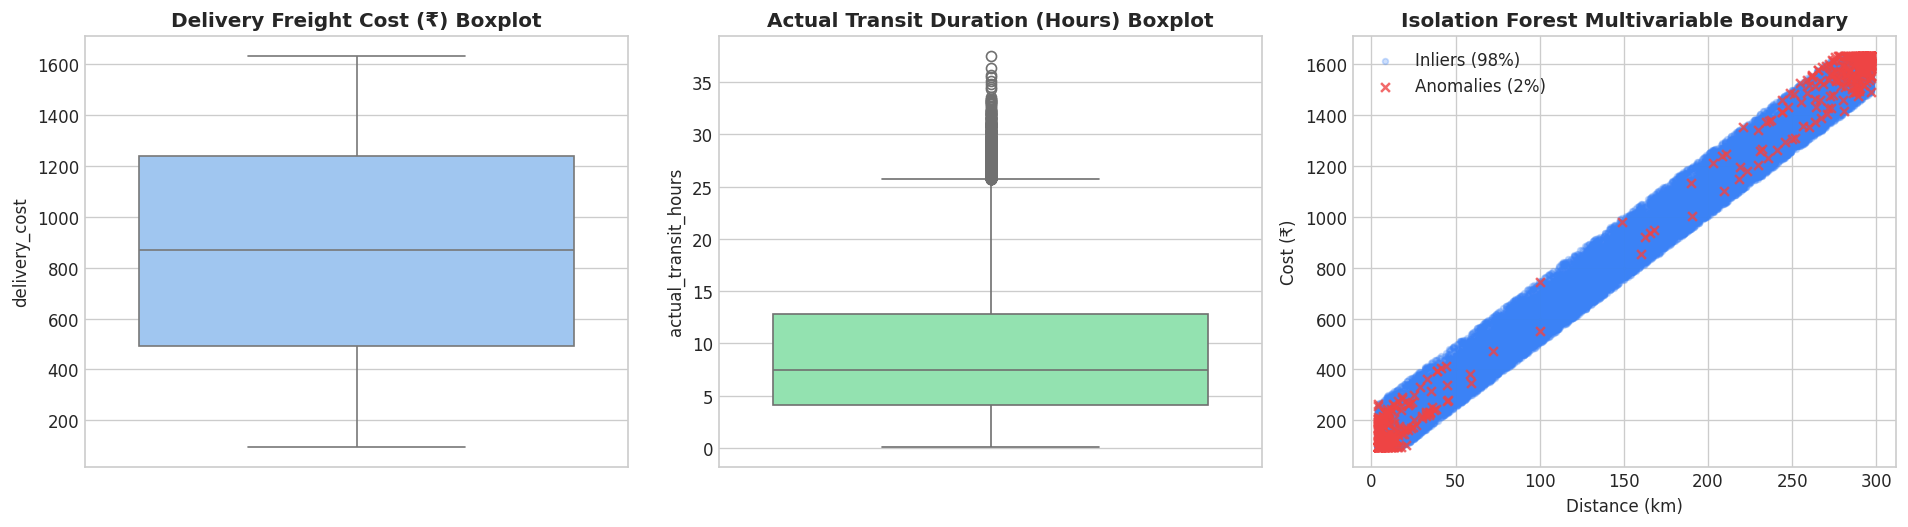

In [6]:
# 1. Isolation Forest Multivariable Outlier Detection
features_for_outliers = ['distance_km', 'package_weight_kg', 'delivery_cost', 'actual_transit_hours']
iso = IsolationForest(contamination=0.02, random_state=42, n_estimators=100)
df['is_anomaly_iso'] = iso.fit_predict(df[features_for_outliers]) == -1

print(f"[*] Isolation Forest flagged {df['is_anomaly_iso'].sum():,} anomalies ({df['is_anomaly_iso'].mean()*100:.2f}%)")

# 2. Quantile Winsorization (1st and 99th Percentile Capping)
for col in ['delivery_cost', 'actual_transit_hours']:
    p01, p99 = df[col].quantile(0.01), df[col].quantile(0.99)
    df[f'{col}_capped'] = df[col].clip(lower=p01, upper=p99)

# Visualize Outlier Profiles
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.boxplot(y=df['delivery_cost'], ax=axes[0], color='#93c5fd')
axes[0].set_title("Delivery Freight Cost (₹) Boxplot", fontweight='bold')

sns.boxplot(y=df['actual_transit_hours'], ax=axes[1], color='#86efac')
axes[1].set_title("Actual Transit Duration (Hours) Boxplot", fontweight='bold')

normal = df[~df['is_anomaly_iso']]
anom = df[df['is_anomaly_iso']]
axes[2].scatter(normal['distance_km'], normal['delivery_cost'], alpha=0.25, s=12, color='#3b82f6', label='Inliers (98%)')
axes[2].scatter(anom['distance_km'], anom['delivery_cost'], alpha=0.8, s=28, color='#ef4444', marker='x', label='Anomalies (2%)')
axes[2].set_title("Isolation Forest Multivariable Boundary", fontweight='bold')
axes[2].set_xlabel("Distance (km)")
axes[2].set_ylabel("Cost (₹)")
axes[2].legend()

plt.tight_layout()
plt.show()


## 7. Supply Chain Feature Engineering
We construct domain-specific operational metrics:
- **Cost per Kilometer (CPK)**: $	ext{CPK} = rac{	ext{Delivery Cost}}{	ext{Distance (km)}}$
- **Cost per Kilogram**: $	ext{Cost/kg} = rac{	ext{Delivery Cost}}{	ext{Package Weight (kg)}}$
- **Green Fleet Indicator (`is_ev`)**: Flags zero-emission vehicles (EV Bike, EV Van).
- **Adverse Weather Risk (`is_adverse_weather`)**: Flags stormy, rainy, or foggy transit.
- **Log Transformations**: $\log(1 + 	ext{Cost})$ and $\log(1 + 	ext{Distance})$ to stabilize variance.


In [7]:
# Advanced Operational Feature Engineering
df['cost_per_km'] = np.round(df['delivery_cost'] / np.maximum(df['distance_km'], 1.0), 2)
df['cost_per_kg'] = np.round(df['delivery_cost'] / np.maximum(df['package_weight_kg'], 0.5), 2)
df['is_ev'] = df['vehicle_type'].apply(lambda x: 1 if 'ev' in str(x) else 0)
df['is_adverse_weather'] = df['weather_condition'].apply(lambda x: 1 if x in ['rainy', 'stormy', 'foggy'] else 0)

# Carrier Reliability Baseline Index
carrier_sla_score = {
    'delhivery': 0.88, 'fedex': 0.87, 'blue dart': 0.86, 'dhl': 0.85,
    'amazon logistics': 0.84, 'ekart': 0.82, 'shadowfax': 0.80,
    'ecom express': 0.79, 'xpressbees': 0.76
}
df['carrier_baseline_reliability'] = df['delivery_partner'].map(carrier_sla_score)

# Log Transformations
df['log_delivery_cost'] = np.round(np.log1p(df['delivery_cost']), 4)
df['log_distance_km'] = np.round(np.log1p(df['distance_km']), 4)

# Target Binaries
df['target_delayed_binary'] = (df['delayed'] == 'yes').astype(int)
df['target_failed_binary'] = (df['delivery_status'] == 'failed').astype(int)

print("[+] Successfully generated all operational supply chain features.")
df[['shipment_uid', 'delivery_partner', 'cost_per_km', 'cost_per_kg', 'is_ev', 'is_adverse_weather', 'carrier_baseline_reliability']].head()


[+] Successfully generated all operational supply chain features.


,shipment_uid,delivery_partner,cost_per_km,cost_per_kg,is_ev,is_adverse_weather,carrier_baseline_reliability
0,DEL-IND-00001,delhivery,5.50,34.77,0,0,0.88
1,DEL-IND-00002,xpressbees,7.14,13.51,1,0,0.76
2,DEL-IND-00003,shadowfax,5.29,53.86,0,1,0.80
3,DEL-IND-00004,dhl,5.51,117.14,1,0,0.85
4,DEL-IND-00005,dhl,5.43,37.67,0,1,0.85


## 8. Feature Scaling & Normalization Benchmarking
We benchmark three fundamental scaling transformations:
1. **StandardScaler**: $z = rac{x - \mu}{\sigma}$ (Centers data at 0 with unit standard deviation).
2. **MinMaxScaler**: $x' = rac{x - x_{min}}{x_{max} - x_{min}}$ (Binds values to $[0.0, 1.0]$).
3. **RobustScaler**: $x_{rob} = rac{x - Q_2}{Q_3 - Q_1}$ (Median and IQR based, robust to outliers).


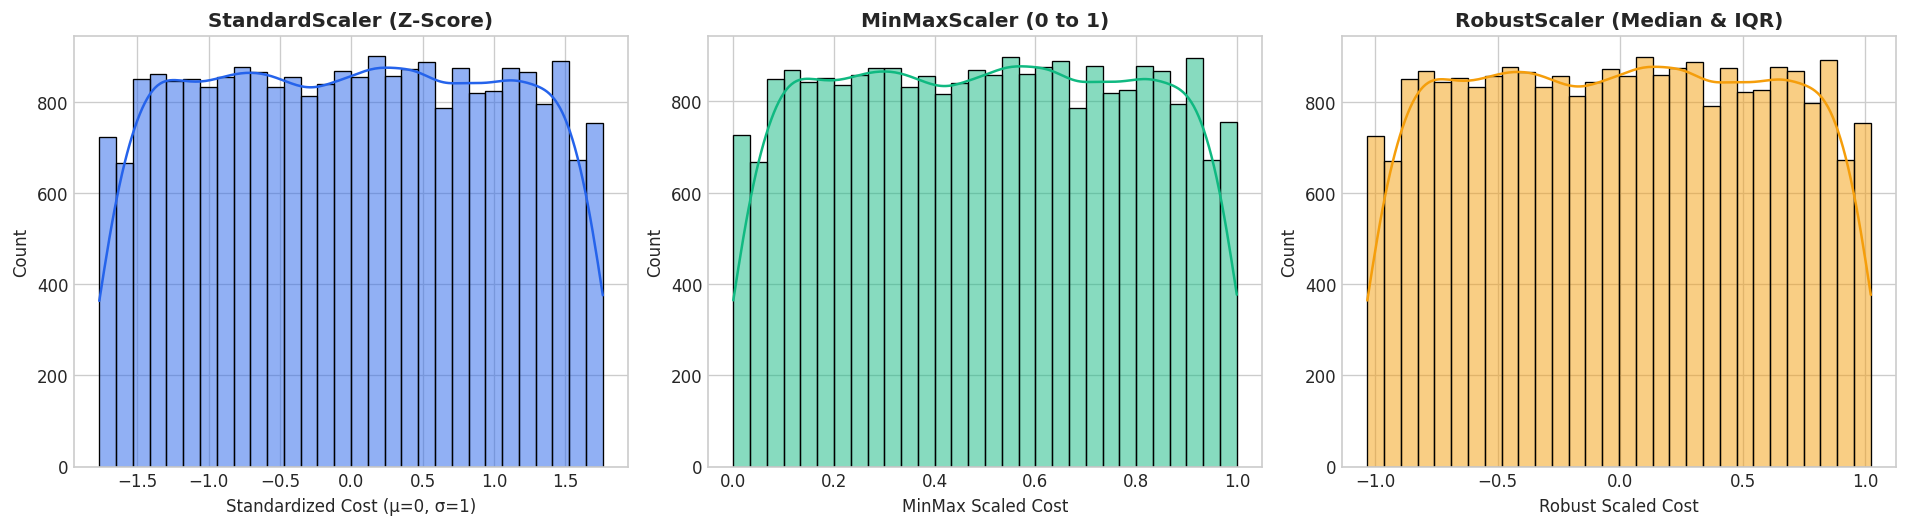

In [8]:
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

num_scale_cols = ['distance_km', 'package_weight_kg', 'delivery_cost', 'actual_transit_hours', 'cost_per_km']

for c in num_scale_cols:
    df[f'{c}_standardized'] = np.round(scaler_std.fit_transform(df[[c]]), 4)
    df[f'{c}_minmax'] = np.round(scaler_minmax.fit_transform(df[[c]]), 4)
    df[f'{c}_robust'] = np.round(scaler_robust.fit_transform(df[[c]]), 4)

# Visualize Scaler Comparison on Delivery Cost
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df['delivery_cost_standardized'], kde=True, ax=axes[0], color='#2563eb', bins=30)
axes[0].set_title("StandardScaler (Z-Score)", fontweight='bold')
axes[0].set_xlabel("Standardized Cost (μ=0, σ=1)")

sns.histplot(df['delivery_cost_minmax'], kde=True, ax=axes[1], color='#10b981', bins=30)
axes[1].set_title("MinMaxScaler (0 to 1)", fontweight='bold')
axes[1].set_xlabel("MinMax Scaled Cost")

sns.histplot(df['delivery_cost_robust'], kde=True, ax=axes[2], color='#f59e0b', bins=30)
axes[2].set_title("RobustScaler (Median & IQR)", fontweight='bold')
axes[2].set_xlabel("Robust Scaled Cost")

plt.tight_layout()
plt.show()


## 9. Multivariable Correlation Heatmap
Verify inter-feature relationships and linear collinearity across clean and engineered features.


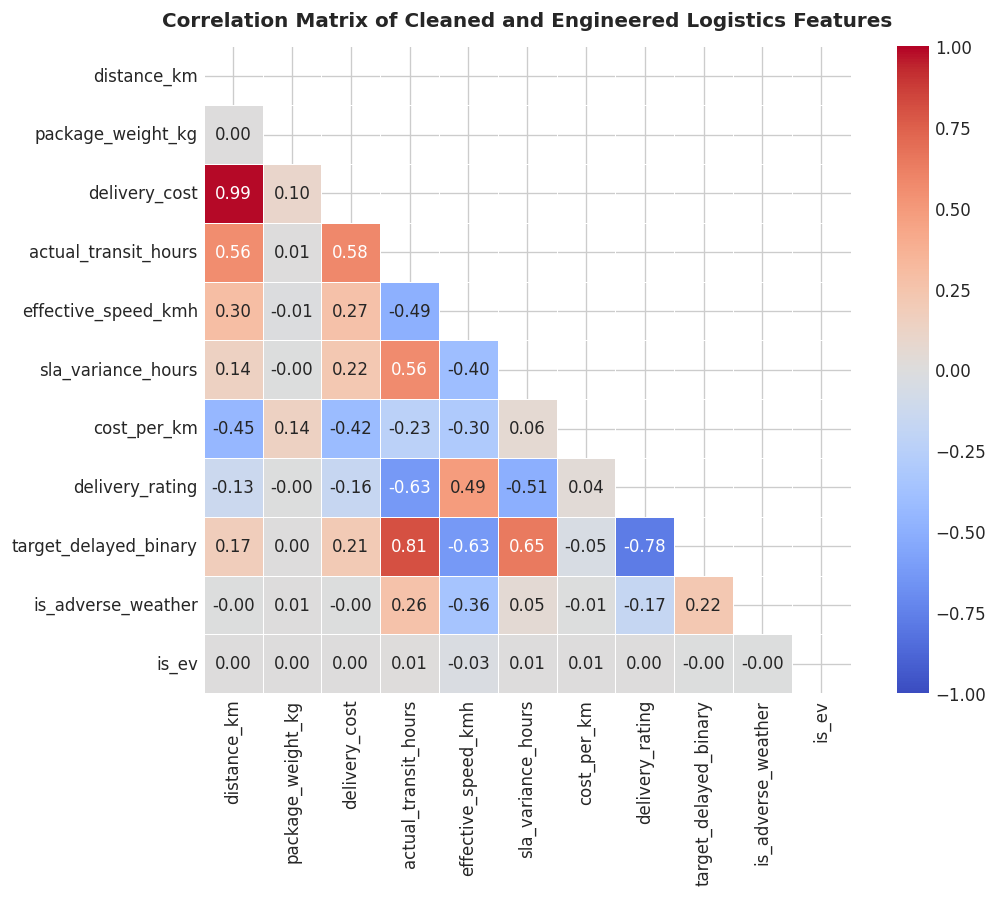

In [9]:
features_for_corr = [
    'distance_km', 'package_weight_kg', 'delivery_cost',
    'actual_transit_hours', 'effective_speed_kmh', 'sla_variance_hours',
    'cost_per_km', 'delivery_rating', 'target_delayed_binary', 'is_adverse_weather', 'is_ev'
]

corr_mat = df[features_for_corr].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

plt.figure(figsize=(10, 7))
sns.heatmap(corr_mat, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Matrix of Cleaned and Engineered Logistics Features", fontweight='bold', pad=12)
plt.show()


## 10. Export Cleaned Dataset & Executive Summary
Export the final cleansed and enriched dataset for downstream modeling.


In [10]:
export_path = "Cleaned_Delivery_Logistics.csv" if os.path.exists("Cleaned_Delivery_Logistics.csv") else "week-2/Cleaned_Delivery_Logistics.csv"
df.to_csv(export_path, index=False)

print(f"[✓] Final Cleaned Dataset Exported: {export_path}")
print(f"[*] Final Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"[*] Total Features Engineered / Standardized: {df.shape[1] - df_raw.shape[1]}")


[✓] Final Cleaned Dataset Exported: Cleaned_Delivery_Logistics.csv
[*] Final Shape: 25,000 rows x 47 columns
[*] Total Features Engineered / Standardized: 32
